## 1. Instalação e Importação de Bibliotecas

In [ ]:
# importação das bibliotecas
# !pip install scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [ ]:
# carregar arquivo .csv enviado para o Colab
df = pd.read_csv('frases_medicas.csv')

print(f'📊 Base carregada: {len(df)} frases')
print()
df.head(10)

📊 Base carregada: 40 frases



,frase,situacao
0,sinto dor no peito e falta de ar,alto risco
1,tive um leve incômodo nas costas,baixo risco
2,estou com febre alta e dificuldade para respirar,alto risco
3,tenho uma dor de cabeça leve,baixo risco
4,sinto formigamento no braço esquerdo e dor no ...,alto risco
5,estou com um pequeno corte no dedo,baixo risco
6,perdi a consciência por alguns segundos,alto risco
7,estou com leve dor de garganta,baixo risco
8,sinto batimentos cardíacos irregulares e tontu...,alto risco
9,tenho um leve cansaço após o exercício,baixo risco


📈 Distribuição das classes:
situacao
alto risco     20
baixo risco    20
Name: count, dtype: int64



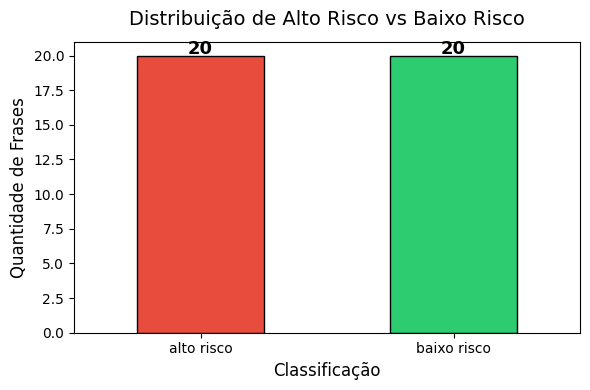

In [ ]:
# Distribuição das classes
print('📈 Distribuição das classes:')
print(df['situacao'].value_counts())
print()

fig, ax = plt.subplots(figsize=(6, 4))
cores = ['#e74c3c', '#2ecc71']
df['situacao'].value_counts().plot(
    kind='bar', ax=ax, color=cores, edgecolor='black', width=0.5
)
ax.set_title('Distribuição de Alto Risco vs Baixo Risco', fontsize=14, pad=12)
ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Quantidade de Frases', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.1),
                ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pré-processamento e Vetorização com TF-IDF

O **TF-IDF** (Term Frequency–Inverse Document Frequency) transforma cada frase em um vetor numérico, atribuindo maior peso às palavras que são importantes para um documento específico, mas raras no conjunto geral — ideal para capturar termos clínicos relevantes.

In [ ]:
X = df['frase']
y = df['situacao']

# Divisão treino/teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'🔀 Divisão dos dados:')
print(f'   Treino : {len(X_train)} frases')
print(f'   Teste  : {len(X_test)} frases')

🔀 Divisão dos dados:
   Treino : 32 frases
   Teste  : 8 frases


In [ ]:
# Vetorização TF-IDF
stopwords_pt = [
    'a', 'ao', 'aos', 'as', 'com', 'da', 'das', 'de', 'do', 'dos',
    'e', 'em', 'eu', 'há', 'me', 'na', 'nas', 'no', 'nos', 'não',
    'o', 'os', 'ou', 'para', 'por', 'que', 'se', 'um', 'uma',
    'após', 'tive', 'tenho', 'sinto', 'estou', 'meu', 'minha', 'pouco'
]

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_features=500,
    sublinear_tf=True,
    stop_words=stopwords_pt
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'✅ Vetorização TF-IDF concluída!')
print(f'   Shape treino : {X_train_tfidf.shape}')
print(f'   Shape teste  : {X_test_tfidf.shape}')
print(f'   Vocabulário  : {len(tfidf.vocabulary_)} termos')

✅ Vetorização TF-IDF concluída!
   Shape treino : (32, 168)
   Shape teste  : (8, 168)
   Vocabulário  : 168 termos


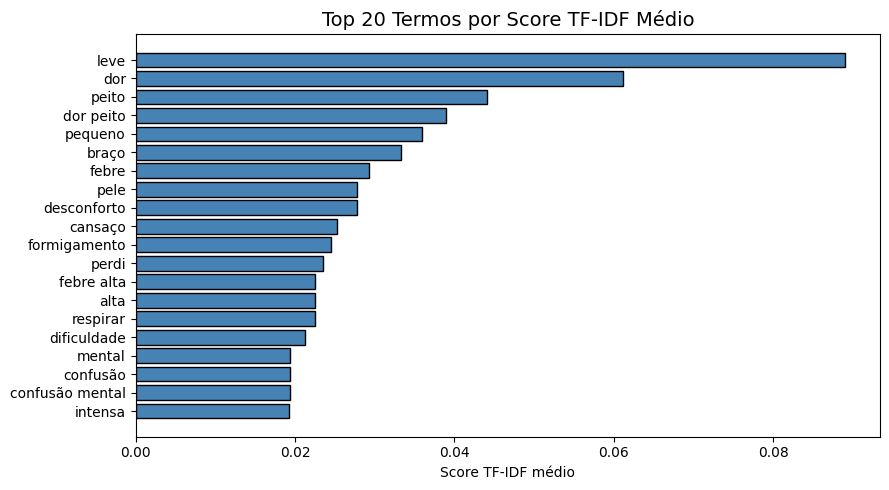

In [ ]:
# Visualizar as palavras com maior peso TF-IDF no conjunto de treino
feature_names = tfidf.get_feature_names_out()
tfidf_scores  = X_train_tfidf.mean(axis=0).A1
top_indices   = tfidf_scores.argsort()[::-1][:20]

top_df = pd.DataFrame({
    'Termo': feature_names[top_indices],
    'Score TF-IDF': tfidf_scores[top_indices]
})

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_df['Termo'][::-1], top_df['Score TF-IDF'][::-1],
        color='steelblue', edgecolor='black')
ax.set_title('Top 20 Termos por Score TF-IDF Médio', fontsize=14)
ax.set_xlabel('Score TF-IDF médio')
plt.tight_layout()
plt.show()

## 4. Treinamento dos Modelos de Classificação

In [ ]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
}

resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)
    acc    = accuracy_score(y_test, y_pred)

    # Cross-validation no conjunto de treino
    cv_scores = cross_val_score(modelo, X_train_tfidf, y_train, cv=5, scoring='accuracy')

    resultados[nome] = {
        'modelo'   : modelo,
        'y_pred'   : y_pred,
        'acuracia' : acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std()
    }

    print(f'\n🤖 {nome}')
    print(f'   Acurácia no teste      : {acc:.2%}')
    print(f'   CV (5-fold) média      : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}')


🤖 Logistic Regression
   Acurácia no teste      : 87.50%
   CV (5-fold) média      : 90.95% ± 11.70%

🤖 Decision Tree
   Acurácia no teste      : 100.00%
   CV (5-fold) média      : 96.67% ± 6.67%


## 5. Avaliação Detalhada do Melhor Modelo

In [ ]:
# Seleciona o melhor modelo pela acurácia no teste
melhor_nome = max(resultados, key=lambda k: resultados[k]['acuracia'])
melhor      = resultados[melhor_nome]

print(f'🏆 Melhor modelo: {melhor_nome} ({melhor["acuracia"]:.2%} de acurácia)')
print()
print('📋 Relatório de Classificação:')
print(classification_report(y_test, melhor['y_pred']))

🏆 Melhor modelo: Decision Tree (100.00% de acurácia)

📋 Relatório de Classificação:
              precision    recall  f1-score   support

  alto risco       1.00      1.00      1.00         4
 baixo risco       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



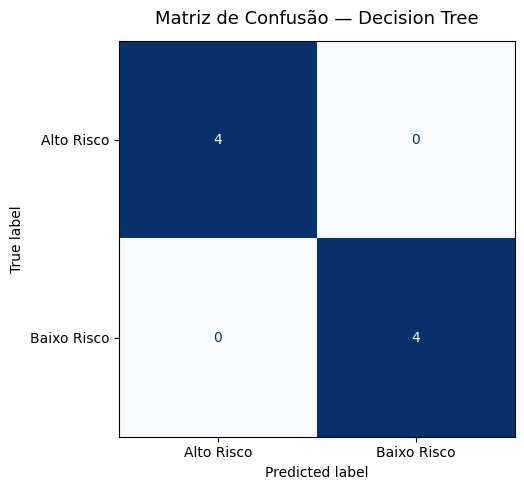


💡 Interpretação:
   • Diagonal principal = classificações CORRETAS
   • Falso Negativo (alto risco classificado como baixo) = risco crítico em triagem
   • Falso Positivo (baixo risco classificado como alto) = sobrecarga desnecessária


In [ ]:
# Matriz de Confusão
cm = confusion_matrix(y_test, melhor['y_pred'], labels=['alto risco', 'baixo risco'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Alto Risco', 'Baixo Risco'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {melhor_nome}', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print('\n💡 Interpretação:')
print('   • Diagonal principal = classificações CORRETAS')
print('   • Falso Negativo (alto risco classificado como baixo) = risco crítico em triagem')
print('   • Falso Positivo (baixo risco classificado como alto) = sobrecarga desnecessária')

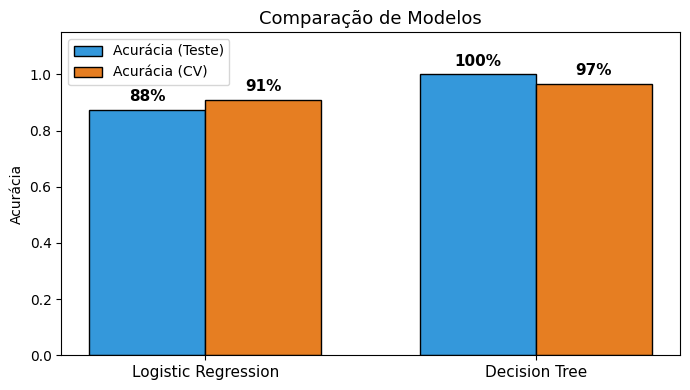

In [ ]:
# Comparação visual entre os modelos
nomes   = list(resultados.keys())
acurs   = [resultados[n]['acuracia'] for n in nomes]
cv_m    = [resultados[n]['cv_mean']  for n in nomes]

x = np.arange(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, acurs, width, label='Acurácia (Teste)',  color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, cv_m,  width, label='Acurácia (CV)',    color='#e67e22', edgecolor='black')

for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.0%}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Modelos', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Teste com Frases Novas (Simulação de Triagem)

In [ ]:
frases_novas = [
    'estou sentindo dor forte no peito e suor excessivo',
    'tenho um leve cansaço e dor nas pernas',
    'não consigo respirar direito e sinto meu coração acelerado',
    'estou com uma leve dor de cabeça desde ontem',
    'perdi a visão de repente e sinto tontura',
    'sinto um pequeno desconforto ao tossir',
]

modelo_final = melhor['modelo']
X_novas      = tfidf.transform(frases_novas)
predicoes    = modelo_final.predict(X_novas)
probabilidades = modelo_final.predict_proba(X_novas)
classes      = modelo_final.classes_

print(f'🏥 Simulação de Triagem Clínica — Modelo: {melhor_nome}')
print('=' * 70)
for frase, pred, proba in zip(frases_novas, predicoes, probabilidades):
    emoji = '🔴' if pred == 'alto risco' else '🟢'
    idx_alto = list(classes).index('alto risco')
    confianca = proba[idx_alto] if pred == 'alto risco' else 1 - proba[idx_alto]
    print(f'{emoji} [{pred.upper():12s}] (conf: {confianca:.0%})')
    print(f'   Frase: "{frase}"')
    print()

🏥 Simulação de Triagem Clínica — Modelo: Decision Tree
🔴 [ALTO RISCO  ] (conf: 100%)
   Frase: "estou sentindo dor forte no peito e suor excessivo"

🟢 [BAIXO RISCO ] (conf: 100%)
   Frase: "tenho um leve cansaço e dor nas pernas"

🔴 [ALTO RISCO  ] (conf: 100%)
   Frase: "não consigo respirar direito e sinto meu coração acelerado"

🟢 [BAIXO RISCO ] (conf: 100%)
   Frase: "estou com uma leve dor de cabeça desde ontem"

🔴 [ALTO RISCO  ] (conf: 100%)
   Frase: "perdi a visão de repente e sinto tontura"

🟢 [BAIXO RISCO ] (conf: 100%)
   Frase: "sinto um pequeno desconforto ao tossir"

